In [1]:
# keras DNN example
# dataset : iris

# load required modules
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# load dataset
dataframe = pd.read_csv("/home/shpark/Projects/Python/DKU-deep-learning/src/dku_deep_learning/ch09/iris.csv")
dataset = dataframe.values
X = dataset[:,0:4].astype(float)
Y = dataset[:,4]
print(dataframe.info())

# encode class values as integers
encoder = LabelEncoder()
encoder.fit(Y)
encoded_Y = encoder.transform(Y)

# convert integers to dummy variables (i.e. one hot encoded)
dummy_y = to_categorical(encoded_Y)

# Divide train, test
X_train, X_test, Y_train, Y_test = train_test_split(X, dummy_y, test_size=0.4, random_state=321)

2025-10-17 22:40:29.915748: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-17 22:40:29.916043: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-17 22:40:29.959087: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-17 22:40:31.122094: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal_Length  150 non-null    float64
 1   Sepal_Width   150 non-null    float64
 2   Petal_Length  150 non-null    float64
 3   Petal_Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [3]:
################################################################
# define model (DNN structure)
epochs = 50
batch_size = 10

model = Sequential()
model.add(Input(shape=(4,)))       # input layer (4 features) 
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.summary()  # show model structure

# Compile model

model.compile(loss='categorical_crossentropy', 
              optimizer='adam', 
              metrics=['accuracy'])

# model fitting (learning)
disp = model.fit(X_train, Y_train, 
                 batch_size=batch_size,
                 epochs=epochs,
                 verbose=1,        # print fitting process  
                 validation_data=(X_test, Y_test))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3667 - loss: 1.0999 - val_accuracy: 0.2833 - val_loss: 1.1514
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3667 - loss: 1.0893 - val_accuracy: 0.2833 - val_loss: 1.1339
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3667 - loss: 1.0804 - val_accuracy: 0.2833 - val_loss: 1.1196
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3667 - loss: 1.0710 - val_accuracy: 0.2833 - val_loss: 1.1056
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3667 - loss: 1.0618 - val_accuracy: 0.2833 - val_loss: 1.0916
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3667 - loss: 1.0528 - val_accuracy: 0.2833 - val_loss: 1.0801
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3667 - loss: 1.0442 - val_accuracy: 0.2833 - val_loss: 1.0731
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3667 - loss: 1.0366 - val_accuracy: 0.2833 - val_loss: 1.0674
Epoch 9

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
[[0.86491203 0.1027454  0.03234254]
 [0.00901109 0.224163   0.76682585]
 [0.01034734 0.24384215 0.7458105 ]
 [0.07630879 0.58507305 0.33861816]
 [0.89514625 0.07844234 0.02641136]
 [0.06561356 0.5939485  0.34043795]
 [0.01214684 0.21202457 0.7758286 ]
 [0.86502236 0.10452829 0.03044931]
 [0.06968136 0.50316525 0.4271534 ]
 [0.8771762  0.09374238 0.02908142]
 [0.8687735  0.09966266 0.03156377]
 [0.901925   0.07641202 0.02166296]
 [0.13705942 0.54395264 0.3189879 ]
 [0.09381413 0.55052876 0.35565716]
 [0.01911515 0.30526283 0.675622  ]
 [0.06054446 0.49979755 0.439658  ]
 [0.00563722 0.18902598 0.80533683]
 [0.86313224 0.10304946 0.03381832]
 [0.04989108 0.4561053  0.4940037 ]
 [0.8474283  0.11764795 0.03492375]
 [0.00518516 0.22302854 0.77178633]
 [0.06650921 0.4757925  0.4576983 ]
 [0.06443188 0.5144172  0.42115098]
 [0.89925975 0.0783039  0.02243634]
 [0.09590615 0.566175   0.3379189 ]
 [0.05734684 0.53060627 0.41204694]
 [0.04584953 0.45858154 0.

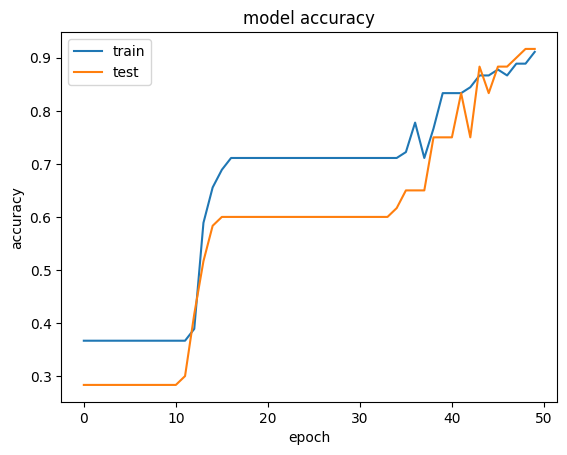

In [4]:
############################################################## 
# Test model
pred = model.predict(X_test)
print(pred)
y_classes = [np.argmax(y, axis=None, out=None) for y in pred]
print(y_classes)   # result of prediction

# model performance
score = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# summarize history for accuracy
plt.plot(disp.history['accuracy'])
plt.plot(disp.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [5]:
############################################################## 
# model weights
for lay in model.layers:
    print(lay.name)
    print(lay.get_weights())

dense_3
[array([[-0.47098136, -0.17060228,  0.0152765 ,  0.22913764,  0.4833449 ,
        -0.336304  ,  0.62720215, -0.3583947 , -0.28503978, -0.22480184],
       [ 0.51843   ,  0.70476604,  0.43388593,  0.38189933,  0.09965793,
        -0.2922678 ,  0.2401962 , -0.3122701 , -0.1795612 , -0.27694854],
       [-0.30850512,  0.02534854,  0.4798016 ,  0.81517696, -0.4469202 ,
        -0.59781814, -0.4573889 , -0.2559242 ,  0.86941105,  0.01995939],
       [-0.45616174, -0.99751806, -0.54568154, -0.1362387 , -0.48505446,
         0.08989382, -0.04885164,  0.57733977,  0.98937136,  0.58097816]],
      dtype=float32), array([ 0.        ,  0.21898443,  0.16765824, -0.06488143,  0.2612077 ,
        0.        ,  0.02600295,  0.        ,  0.12626301,  0.        ],
      dtype=float32)]
dense_4
[array([[ 0.32733166, -0.4192792 ,  0.35722947,  0.3518582 , -0.4336037 ,
        -0.35903448,  0.24692339,  0.19961566, -0.43706048, -0.28430134],
       [-0.30594918, -0.15503201,  0.145305  ,  0.9392315